# Detecção de fraudes em transações

Professora: Dra. Isadora Garcia Ferrão

Aluno: Jesus Wildes Suathê Farias

In [30]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Problema de classificação desbalanceada

Fraudes são raras -> modelo pode ignorar a classe 1

In [3]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

## Feature Engineering

Criamos variáveis que ajudam o modelo

In [4]:
df["Amount_log"] = np.log1p(df["Amount"])

In [8]:
scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [12]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

## Logistic Regression

In [17]:
model = LogisticRegression(max_iter=100000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.65      0.74       148

    accuracy                           1.00     85443
   macro avg       0.92      0.82      0.87     85443
weighted avg       1.00      1.00      1.00     85443



Accuracy pode ser alta mesmo sem detectar fraudes.

Por isso usamos:
- Recall(o mais importante)
- Precision
- F1-score

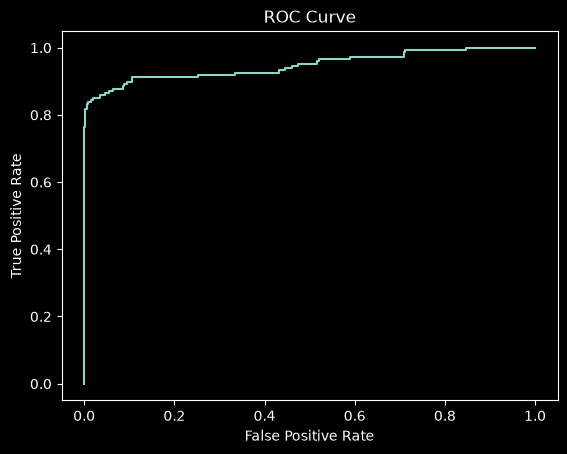

AUC: 0.9475020715069955


In [20]:
y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

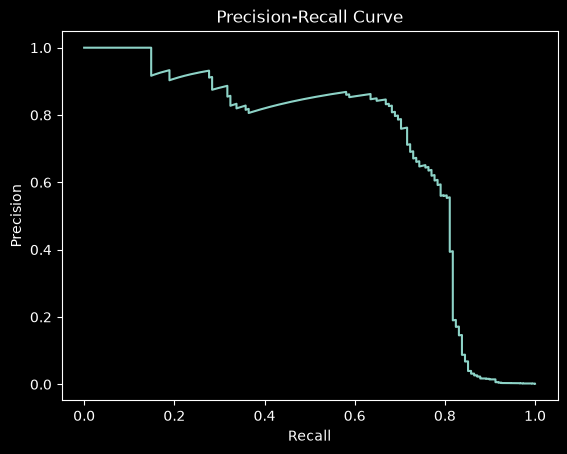

In [22]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## Balanceamento de dados

In [23]:
# Undersampling
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [26]:
# Oversampling
smote = SMOTE()

X_res, y_res = smote.fit_resample(X, y)

In [29]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.74      0.80      0.77       148

    accuracy                           1.00     85443
   macro avg       0.87      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443



In [33]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [34]:
threshold = -.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     85295
           1       0.00      1.00      0.00       148

    accuracy                           0.00     85443
   macro avg       0.00      0.50      0.00     85443
weighted avg       0.00      0.00      0.00     85443



/home/eitaro/miniconda3/envs/accenture-python/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/eitaro/miniconda3/envs/accenture-python/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/eitaro/miniconda3/envs/accenture-python/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p